In [ ]:
# statistical testing
from scipy.stats import fisher_exact
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from scipy.stats import norm
import math

# modules for data processing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# data processing for both control and
df_CONTROL = pd.read_excel("RawData.xlsx", sheet_name="Control ")
df_EXPERIMENT = pd.read_excel("RawData.xlsx", sheet_name="Experiment")

In [ ]:
# toy code
contingency_table = [[10, 5], [3, 12]]

# Perform Fisher's exact test (two-sided)
odds_ratio, p_value = fisher_exact(contingency_table, alternative='two-sided')

# Print the results
print(f"Contingency Table: {contingency_table}")
print(f"Odds Ratio: {odds_ratio:.4f}")
print(f"P-value: {p_value:.4f}")

# Compare p-value to significance level (alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print("Conclusion: There is a statistically significant association between gender and political party preference.")
else:
    print("Conclusion: There is no statistically significant association between gender and political party preference.")


Contingency Table: [[10, 5], [3, 12]]
Odds Ratio: 8.0000
P-value: 0.0253
Conclusion: There is a statistically significant association between gender and political party preference.


In [ ]:
# toy code
# Define two distinct data samples
data1 = np.array([31, 22, 39, 27, 35, 28, 34, 26, 23, 33])
data2 = np.array([26, 25, 30, 28, 29, 28, 27, 30, 27, 28])

# Perform the Mann-Whitney U test
# 'two-sided' is the recommended alternative hypothesis for general use
u_statistic, p_value = mannwhitneyu(data1, data2, alternative='two-sided')

# Print the test statistic and p-value
print(f"U-value: {u_statistic}")
print(f"p-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("The p-value is less than the significance level (0.05). We reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference between the two groups.")
else:
    print("The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference between the two groups.")

U-value: 60.0
p-value: 0.4699923731723571
The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the two groups.


N_Control:  28
N_Experiment: 40
N_Control Median:  10.5
N_Experiment Median:  10.5


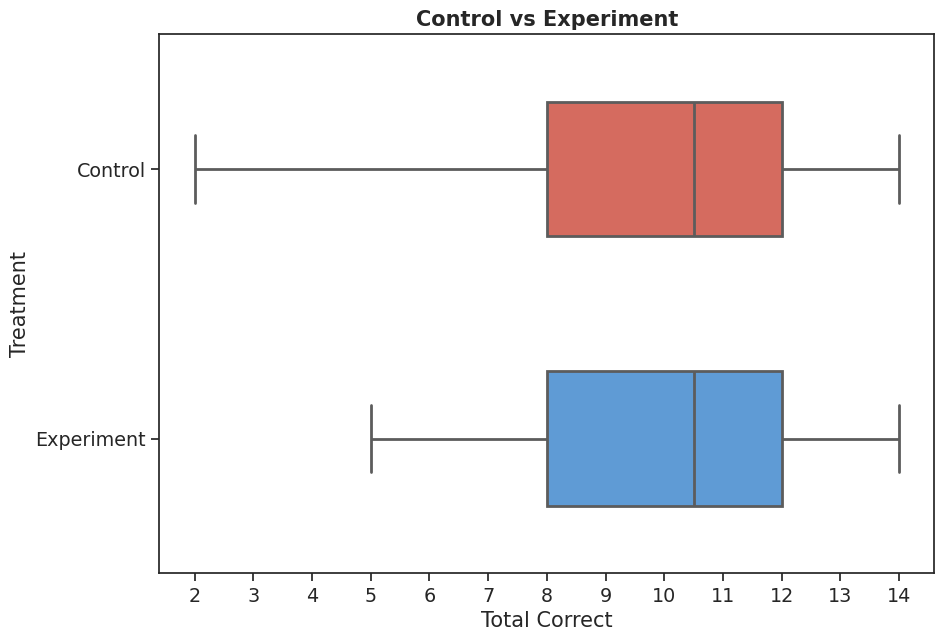

<Figure size 800x600 with 0 Axes>

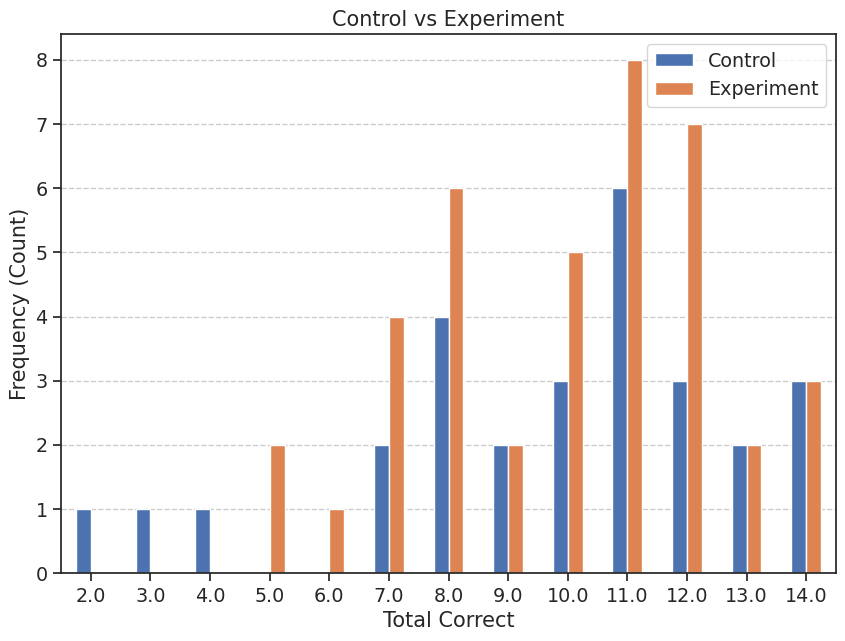

In [ ]:
# mann-whitney u-test data representation
data_control = df_CONTROL.iloc[63]
data_experiment = df_EXPERIMENT.iloc[63]

# convert to a normal list (then back to a dataframe) and exclude the last four values because the data points are unclear and contains NaN and has no entry of the person
# code could be simpler here but no time to simplify
data_control_clean = pd.DataFrame({
    'Improvement': pd.to_numeric(data_control[:-4], errors='coerce').dropna(),
    'Treatment': 'Control'
})
data_experiment_clean = pd.DataFrame({
    'Improvement': pd.to_numeric(data_experiment[:-4], errors='coerce').dropna(),
    'Treatment': 'Experiment'
})

print("N_Control: ", len(data_control_clean))
print("N_Experiment:", len(data_experiment_clean))

print("N_Control Median: ", np.median(data_control_clean['Improvement']))
print("N_Experiment Median: ", np.median(data_experiment_clean['Improvement']))

# merge the two lists together as a dataframe
data_control_clean['Treatment'] = 'Control'
data_experiment_clean['Treatment'] = 'Experiment'
data_to_plot = pd.concat([data_control_clean, data_experiment_clean])
data_to_plot.head(80)

# box plot
# data_to_plot = [data_control_clean, data_experiment_clean]

# plt.boxplot(data_to_plot, labels=['Control', 'Experiment'])
# plt.title('Control vs Experiment')
# plt.ylabel('Total Correct')

def conv_treat_readable(treatment):
    if treatment == True:
        return 'Gamified'
    else:
        return 'Not Gamified'

sns.set_theme(rc={'figure.figsize':(10,7)}) # sets default plot size
sns.set_style('ticks')
sns.set_context('notebook',font_scale=1.25)

ax = sns.boxplot(
    data=data_to_plot,
    x='Improvement',
    y='Treatment',
    hue='Treatment', # Assigns hue based on 'Treatment' column value
    width=0.5,
    linewidth=2,
    palette={'Experiment': '#4C9BE8', 'Control': '#E85C4C'},
)

loc = mpl.ticker.MultipleLocator(base=1.0) # this locator puts ticks at regular intervals. ticker is the tick library. MultipleLocator is the regular interval tick class.
ax.xaxis.set_major_locator(loc)

plt.xlabel('Total Correct')
plt.title('Control vs Experiment', fontweight='bold')

# bar graph
data_series_control = pd.Series(data_control_clean['Improvement'])
data_series_experiment = pd.Series(data_experiment_clean['Improvement'])

counts_control = data_series_control.value_counts().sort_index()
counts_experiment = data_series_experiment.value_counts().sort_index()

counts_df = pd.DataFrame({
    'Control': counts_control,
    'Experiment': counts_experiment
}).fillna(0)

plt.figure(figsize=(8, 6))
counts_df.plot(kind='bar')

plt.title('Control vs Experiment')
plt.xlabel('Total Correct')
plt.ylabel('Frequency (Count)')
plt.xticks(rotation=0) # Keeps the x-axis labels horizontal
plt.grid(axis='y', linestyle='--')

plt.show()

U-value: 556.5
p-value: 0.48495123083071323
The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the two groups.
560.0 80.24961059095551


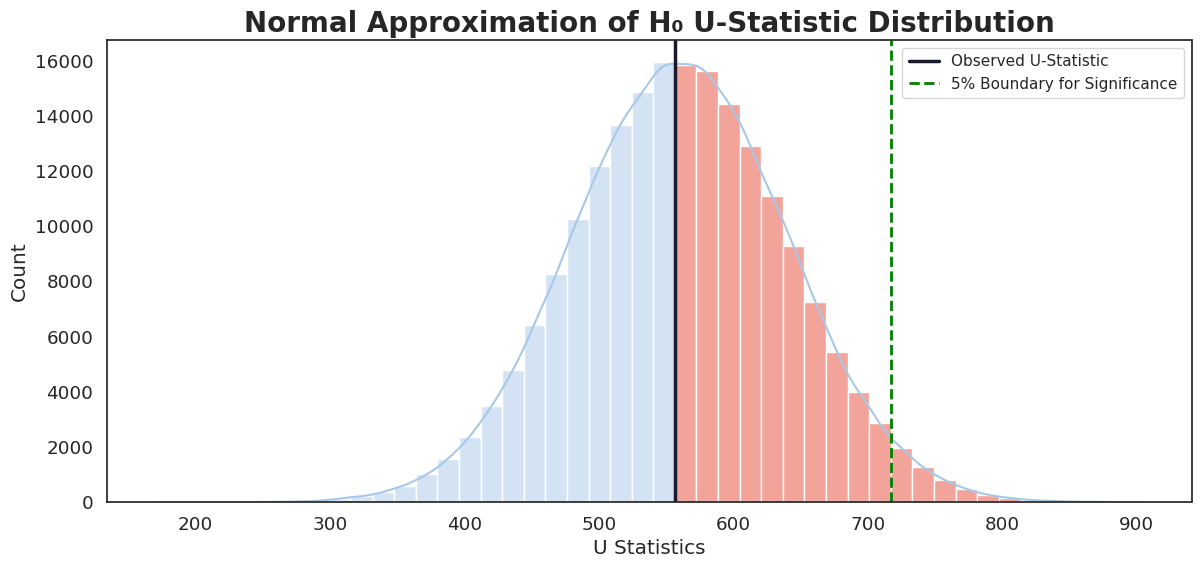

In [ ]:
# mann-whitney test using Q60 row

"""
Mann-Whitney Conditions:
 - Independent observations
 - Two independent groups
 - Ordinal or continuous dependent variable
 - Similarity of distribution shape

Current Situ:
 - All the data points are independent of each other - there are different students in each group
 - The total correct is independent for groups Control and Experiment
 - Total correct are rankable
 - The shape of the distributions of both Control and Experiment total correct are similar
   -> test of median
   Visually confirmed using the boxplot given above
 (NOTE - if it were not similar, it would have meant that it tests general distribution differences)
"""

data1 = np.array(data_control_clean['Improvement'])
data2 = np.array(data_experiment_clean['Improvement'])

"""
Null Hypothesis: The median of control(PowerPoint) and experiment(GLE) total correct is the same

Alternative Hypothesis: The median of control's(PowerPoint) total correct is less
                        compared to the experiment's(GLE) total correct median
"""

u_statistic, p_value = mannwhitneyu(data1, data2, alternative='less')
print(f"U-value: {u_statistic}")
print(f"p-value: {p_value}")

alpha = 0.05
if p_value < alpha:
    print("The p-value is less than the significance level (0.05). We reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference between the two groups.")
else:
    print("The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference between the two groups.")

"""
Because the p-value (0.485) is greater than 0.05, we fail to reject the null hypothesis.
There is insufficient evidence to conclude that the median total correct score of the control(PowerPoint) group is
lower than that of the median total correct score experimental(GLE) group. Because the sample was not randomly
selected, the results are limited to the participants in this study and may not generalize to a broader population.

--> the overall median performance does not have significant difference between the PowerPoint and GLE for groups
    similar to the study essentially.(testing does not confirm)
"""

# Use normal approximation of H_0 u-statistic dist since n1, n2 > 20
n1 = len(data1)
n2 = len(data2)
norm_mean = n1*n2/2
norm_stdev = math.sqrt(n1 * n2 * (n1+n2+1)/12)
print(norm_mean, norm_stdev)
np.random.seed(0)
x = np.random.normal(size=200000)*norm_stdev + norm_mean
y = norm.pdf(x, loc=norm_mean, scale=norm_stdev)
# Plot this normal approximation distribution
sns.set_theme(style='white', font_scale=1.2)
plt.rcParams['figure.figsize'] = (8, 5)
fig, axes = plt.subplots(1, 1, figsize=(14, 6))
sns.histplot(
    x,
    color="#A8C8E8",
    ax=axes,
    bins=40,
    binrange=[u_statistic-4*norm_stdev, u_statistic+4*norm_stdev],
    kde=True
)
axes.set_title('Normal Approximation of H₀ U-Statistic Distribution', fontsize=20, fontweight='bold') # Meaning if H₀ was true, then the distribution of possible u-statistics looks like this
axes.set_xlabel('U Statistics')
axes.axvline(x=u_statistic, color='#1a1a2e', linestyle='-', linewidth=2.5, label=f'Observed U-Statistic')
axes.axvline(x=norm_mean+1.96*norm_stdev, color='green', linestyle='--', linewidth=2, label=f'5% Boundary for Significance')
for i in range(20, 40):
  axes.patches[i].set_facecolor("#F2A39A")
axes.legend(fontsize=11)

In [ ]:
# fisher's exact test data representation
"""
Mosaic plot may be used
"""

# data processing
"""
Using Q11(pre-test correct) and Q53(revisit_correct) to see if there is a change in performance
0 = both correct
1 = wrong -> correct  (improvement)
2 = correct -> wrong  (decline)
3 = both wrong
"""
# pre-test correct
dt_control_PreC = df_CONTROL.iloc[12]
dt_experiment_PreC = df_EXPERIMENT.iloc[12]

# revisit correct
dt_control_PostC = df_CONTROL.iloc[56]
dt_experiment_PostC = df_EXPERIMENT.iloc[56]

# clean the arrays
dt_control_PreC_clean = pd.to_numeric(dt_control_PreC[:-4], errors='coerce').dropna().reset_index(drop=True)
dt_experiment_PreC_clean = pd.to_numeric(dt_experiment_PreC[:-4], errors='coerce').dropna().reset_index(drop=True)

dt_control_PostC_clean = pd.to_numeric(dt_control_PostC[:-4], errors='coerce').dropna().reset_index(drop=True)
dt_experiment_PostC_clean = pd.to_numeric(dt_experiment_PostC[:-4], errors='coerce').dropna().reset_index(drop=True)

print("Pre-Test Control Correct: ", len(dt_control_PreC_clean))
print("Pre-Test Experiment Correct: ", len(dt_experiment_PreC_clean))
print("Revisit Control Correct: ", len(dt_control_PostC_clean))
print("Revisit Experiment Correct: ", len(dt_experiment_PostC_clean))

# reorganized data
reorganizedData_Control = []
reorganizedData_Experiment = []

# control
for i in range(len(dt_control_PreC_clean)):
    pre = dt_control_PreC_clean[i]
    post = dt_control_PostC_clean[i]
    if pre == 0 and post == 0:
        reorganizedData_Control.append(3)
    elif pre == 1 and post == 0:
        reorganizedData_Control.append(2)
    elif pre == 0 and post == 1:
        reorganizedData_Control.append(1)
    elif pre == 1 and post == 1:
        reorganizedData_Control.append(0)

# experiment
for i in range(len(dt_experiment_PreC_clean)):
    pre = dt_experiment_PreC_clean[i]
    post = dt_experiment_PostC_clean[i]
    if pre == 0 and post == 0:
        reorganizedData_Experiment.append(3)
    elif pre == 1 and post == 0:
        reorganizedData_Experiment.append(2)
    elif pre == 0 and post == 1:
        reorganizedData_Experiment.append(1)
    elif pre == 1 and post == 1:
        reorganizedData_Experiment.append(0)

print(reorganizedData_Control)
print("Length_Control:", len(reorganizedData_Control))
print(reorganizedData_Experiment)
print("Length_Experiment:", len(reorganizedData_Experiment))

improvedCounter_Control = 0
improvedCounter_Experiment = 0
for i in range(len(reorganizedData_Control)):
    if reorganizedData_Control[i] == 1:
        improvedCounter_Control+=1

for i in range(len(reorganizedData_Experiment)):
    if reorganizedData_Experiment[i] == 1:
        improvedCounter_Experiment+=1

# essentially the countres for 1s
print("Key = 1, Control: ", improvedCounter_Control)
print("Key = 1, Experiment: ", improvedCounter_Experiment)

# function to count how many occurence of a number appears
def count_num(num, list):
    count = 0
    for i in list:
        if i == num:
            count +=1

    return count

# conclusion functions
def conclusion(p_value, alpha = 0.05):
    if p_value < alpha:
        print("The p-value is less than the significance level (0.05). We reject the null hypothesis.")
        print("Conclusion: There is a statistically significant difference between the two groups.")
    else:
        print("The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.")
        print("Conclusion: There is no statistically significant difference between the two groups.")


Pre-Test Control Correct:  28
Pre-Test Experiment Correct:  40
Revisit Control Correct:  28
Revisit Experiment Correct:  40
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 3, 0]
Length_Control: 28
[0, 0, 3, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 1, 0, 0, 1, 3, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length_Experiment: 40
Key = 1, Control:  4
Key = 1, Experiment:  4


In [ ]:
# fisher's exact test
"""
Fisher's Exact Test Conditions:
 - Categorical data(counts only)
 - Two categorical data
 - 2 x 2 contingency table
 - Independence of Observations
 - Small sample or low expected counts(expected counts are below 5)

Current Situ:
 - All data are categorical(given states of 0, 1, 2, and 3, provided above)
 - The categorical data collected is if the selected answer correct or incorrect
 - See below
 - The observations for each data are independent from each other
 - See below

General structure of contingency table
Structure
            | No/Decreased Improvement(0) |  Improved(1)  |
Control     |                             |               |
Experiment  |                             |               |

Expected Counts
            | No/Decreased Improvement(0) |  Improved(1)  |
Control     |            24.71            |     3.29      |
Experiment  |            35.29            |     4.71      |
Small sample condition is met bc two of the boxes are <5
"""
# comparison analysis
contingency_table = [
    [len(reorganizedData_Control) - improvedCounter_Control, improvedCounter_Control],
    [len(reorganizedData_Experiment) - improvedCounter_Experiment, improvedCounter_Experiment]
]

control_no_improve = contingency_table[0][0]
control_improve = contingency_table[0][1]
exp_no_improve = contingency_table[1][0]
exp_improve = contingency_table[1][1]

grand_total = control_no_improve + control_improve + exp_no_improve + exp_improve

table_data = {
    'No/Decreased Improvement': [control_no_improve, exp_no_improve, control_no_improve + exp_no_improve],
    'Improved': [control_improve, exp_improve, control_improve + exp_improve],
    'Row Total': [control_no_improve + control_improve, exp_no_improve + exp_improve, grand_total]
}

contingency_df = pd.DataFrame(table_data, index=['Control', 'Experiment', 'Column Total'])
print(contingency_df)

print("\n" * 10)

"""
Null hypothesis: There are no association between the control and experiment that improved in answering
                 the question correctly

Alternative Hypothesis: There is an assoication between the control and experiment that improved in answering the
                        question correctly

* Experiment(GLE) should increase of accuracy for the questions
"""
odds_ratio, p_value = fisher_exact(contingency_table, alternative='less')

print(f"Contingency Table_NC: {contingency_table}")
print(f"Odds Ratio_NC: {odds_ratio}")
print(f"P-value_NC: {p_value}")

conclusion(p_value)

"""
Because the p-value (0.431) is greater than 0.05, we fail to reject the null hypothesis.
There is insufficient evidence to conclude that there is an association where the experimental group improved in answering the question correctly compared to the control group.
"""

              No/Decreased Improvement  Improved  Row Total
Control                             24         4         28
Experiment                          36         4         40
Column Total                        60         8         68











Contingency Table_NC: [[24, 4], [36, 4]]
Odds Ratio_NC: 0.6666666666666666
P-value_NC: 0.4310794567391593
The p-value is greater than the significance level (0.05). We fail to reject the null hypothesis.
Conclusion: There is no statistically significant difference between the two groups.


'\nBecause the p-value (0.431) is greater than 0.05, we fail to reject the null hypothesis.\nThere is insufficient evidence to conclude that there is an association where the experimental group improved in answering the question correctly compared to the control group.\n'